In [1]:
import sys

sys.path.append("..")

from dataclasses import dataclass
from typing import Callable

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
import numpy as np
import random
from pulp import *
import cma

In [2]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
    plot_lp_result,
    plot_lp_swap_result,
)

from calculation.calculation import find_farthest_pair, find_farthest_triple

from lp.lp import (
    PermutationLpModel,
    exclude_current_solution,
    exclude_largest_variable
)

In [3]:
# https://claude.ai/share/38d5e708-a9f6-456d-b1f1-69be59d9f84c

Genom to ciąg liczb opisujących całe wybory. Genom składa się z dwóch częsci.
1. $m$ kandydatów, dla każdego para współrzędnych $(x,y)$, więc razem $2m$ zmiennych
2. $G$ skupisk, gdzie każde skupisko opisane jest czterema liczbami: położeniem środka $(x,y)$, rozrzutem i wagą. Łącznie $4G$ zmiennych.

Łącznie jeden genom jest $(2m+4G)$ wymiarowy.

In [4]:
@dataclass
class GenomeConfig:
    n_candidates: int
    n_clusters: int
    bounds_x: tuple[float, float] = (-10.0, 10.0)
    bounds_y: tuple[float, float] = (-10.0, 10.0)
    spread_bounds: tuple[float, float] = (0.5, 5.0)
    weight_bounds: tuple[float, float] = (0.0, 1.0)

    @property
    def genome_length(self) -> int:
        return 2 * self.n_candidates + 4 * self.n_clusters

    @property
    def lower_bounds(self) -> list[float]:
        candidate_lb = [self.bounds_x[0], self.bounds_y[0]] * self.n_candidates
        cluster_lb = [
            self.bounds_x[0],
            self.bounds_y[0],
            self.spread_bounds[0],
            self.weight_bounds[0],
        ] * self.n_clusters
        return candidate_lb + cluster_lb

    @property
    def upper_bounds(self) -> list[float]:
        candidate_ub = [self.bounds_x[1], self.bounds_y[1]] * self.n_candidates
        cluster_ub = [
            self.bounds_x[1],
            self.bounds_y[1],
            self.spread_bounds[1],
            self.weight_bounds[1],
        ] * self.n_clusters
        return candidate_ub + cluster_ub

    def random_genome(self, rng: np.random.Generator) -> np.ndarray:
        lb = np.array(self.lower_bounds)
        ub = np.array(self.upper_bounds)
        return lb + rng.random(self.genome_length) * (ub - lb)


@dataclass
class VoterCluster:
    center: tuple[float, float]
    spread: float
    weight: float


def decode_genome(
    genome: np.ndarray, config: GenomeConfig
) -> tuple[list[Candidate], list[VoterCluster]]:
    genome = np.asarray(genome)
    n_candidate_genes = 2 * config.n_candidates

    candidate_genes = genome[:n_candidate_genes]
    candidates = [
        Candidate(id=i, position=(candidate_genes[2 * i], candidate_genes[2 * i + 1]))
        for i in range(config.n_candidates)
    ]

    cluster_genes = genome[n_candidate_genes:]
    clusters = [
        VoterCluster(
            center=(cluster_genes[4 * g], cluster_genes[4 * g + 1]),
            spread=max(cluster_genes[4 * g + 2], 1e-3),
            weight=max(cluster_genes[4 * g + 3], 0.0),
        )
        for g in range(config.n_clusters)
    ]

    return candidates, clusters


def generate_voters(
    clusters: list[VoterCluster], n_voters: int, rng: np.random.Generator
) -> list[Voter]:
    weights = np.array([c.weight for c in clusters])
    if weights.sum() <= 0:
        weights = np.ones(len(clusters))
    probs = weights / weights.sum()

    cluster_choices = rng.choice(len(clusters), size=n_voters, p=probs)
    voters = []
    for idx in cluster_choices:
        cluster = clusters[idx]
        position = rng.normal(loc=cluster.center, scale=cluster.spread, size=2)
        voters.append(Voter(position=position))
    return voters

In [5]:
def evaluate_genome(
    genome: np.ndarray,
    config: GenomeConfig,
    strategies: list[VotingStrategy],
    n_voters: int,
    rng: np.random.Generator,
) -> float:
    candidates, clusters = decode_genome(genome, config)
    voters = generate_voters(clusters, n_voters, rng)
    election = Election(candidates, voters)
    result = election.compare_strategies(strategies)
    analyzer = ResultsAnalyzer([result])
    return analyzer.mean_pairwise_winner_distance(result)


class EvolutionaryElection:
    def __init__(
        self,
        config: GenomeConfig,
        strategies: list[VotingStrategy],
        n_voters: int = 200,
        sigma0: float = 2.0,
        seed: int | None = None,
        popsize: int | None = None,
    ):
        self.config = config
        self.strategies = strategies
        self.n_voters = n_voters
        self.rng = np.random.default_rng(seed)

        x0 = config.random_genome(self.rng)
        ranges = np.array(config.upper_bounds) - np.array(config.lower_bounds)
        opts = {
            "bounds": [config.lower_bounds, config.upper_bounds],
            "seed": seed if seed is not None else np.nan,
            # Per-dimension scale so a single sigma0 makes sense across genes with
            # very different ranges (positions vs. spread vs. weight).
            "CMA_stds": (ranges / ranges.max()).tolist(),
        }
        if popsize is not None:
            opts["popsize"] = popsize

        self.es = cma.CMAEvolutionStrategy(x0, sigma0, opts)
        self.history: list[float] = []
        # Best genome of each generation, kept in sync with self.history so the
        # whole run can be replayed/animated afterwards.
        self.genome_history: list[np.ndarray] = []

    def _fitness(self, genome: np.ndarray) -> float:
        score = evaluate_genome(
            genome, self.config, self.strategies, self.n_voters, self.rng
        )
        # cma minimizes, but we want to maximize the disagreement between strategies
        return -score

    def step(self) -> float:
        solutions = self.es.ask()
        fitnesses = [self._fitness(np.array(x)) for x in solutions]
        self.es.tell(solutions, fitnesses)
        best_idx = int(np.argmin(fitnesses))
        best = -fitnesses[best_idx]
        self.history.append(best)
        self.genome_history.append(np.array(solutions[best_idx]))
        return best

    def run(self, n_generations: int = 50, verbose: bool = False) -> np.ndarray:
        for gen in range(n_generations):
            best = self.step()
            if verbose:
                print(f"gen {gen:3d}: best mean pairwise winner distance = {best:.4f}")
        return self.best_genome()

    def best_genome(self) -> np.ndarray:
        return np.array(self.es.result.xbest)

    def best_election(self) -> Election:
        candidates, clusters = decode_genome(self.best_genome(), self.config)
        voters = generate_voters(clusters, self.n_voters, self.rng)
        return Election(candidates, voters)

In [6]:
config = GenomeConfig(n_candidates=8, n_clusters=10)
strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]

evo = EvolutionaryElection(config, strategies, n_voters=1000, sigma0=2.0)
evo.run(n_generations=20, verbose=True)

best_election = evo.best_election()
best_result = best_election.compare_strategies(strategies, label="best genome")
best_result.winners()


(8_w,16)-aCMA-ES (mu_w=4.8,w_1=32%) in dimension 56 (seed=nan, Sun Jun 21 18:21:08 2026)
gen   0: best mean pairwise winner distance = 9.7929
gen   1: best mean pairwise winner distance = 13.2292
gen   2: best mean pairwise winner distance = 14.2987
gen   3: best mean pairwise winner distance = 13.5128
gen   4: best mean pairwise winner distance = 14.9679
gen   5: best mean pairwise winner distance = 14.6052
gen   6: best mean pairwise winner distance = 15.1652
gen   7: best mean pairwise winner distance = 17.5845
gen   8: best mean pairwise winner distance = 15.7001
gen   9: best mean pairwise winner distance = 16.6571
gen  10: best mean pairwise winner distance = 16.0804
gen  11: best mean pairwise winner distance = 16.3602
gen  12: best mean pairwise winner distance = 16.8634
gen  13: best mean pairwise winner distance = 17.3423
gen  14: best mean pairwise winner distance = 17.4756
gen  15: best mean pairwise winner distance = 17.3251
gen  16: best mean pairwise winner distance = 18

{'Plurality rule': Candidate(id=6, position=(np.float64(9.987827534860179), np.float64(2.330814314657993))),
 'Borda count': Candidate(id=4, position=(np.float64(-6.25445873633028), np.float64(6.717202165707878))),
 'Veto rule': Candidate(id=0, position=(np.float64(-9.843193416623496), np.float64(-8.411142036268796)))}

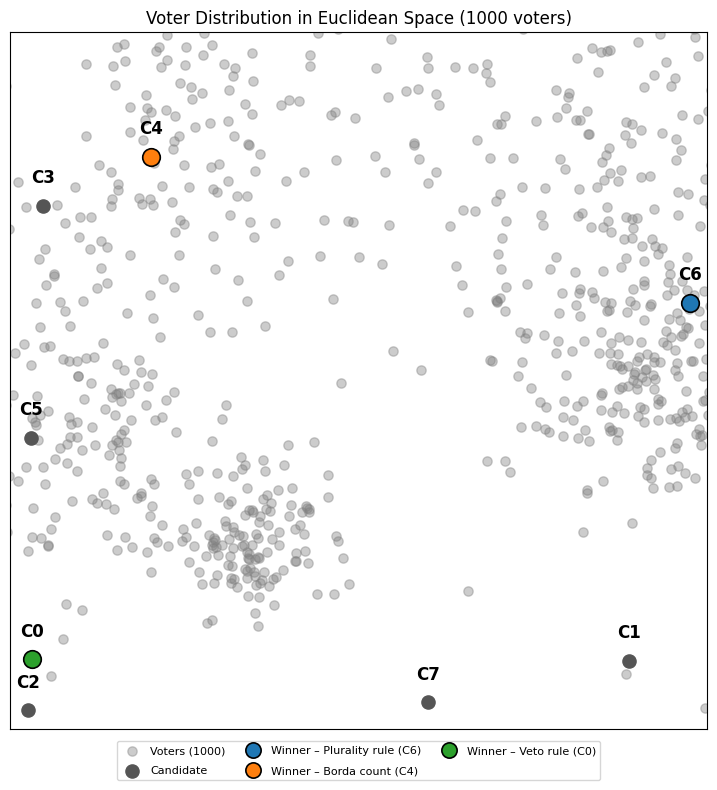

In [7]:
plot_results(best_result)

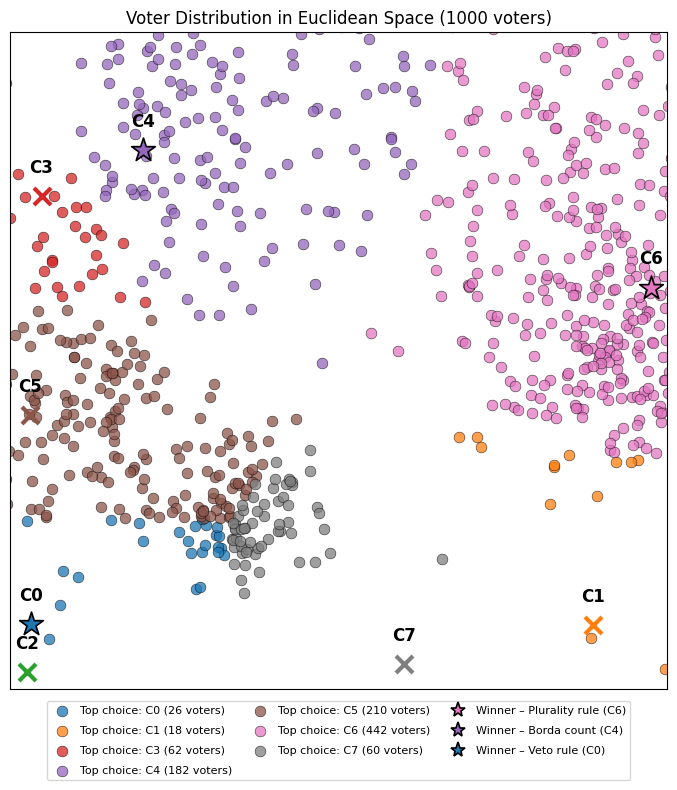

In [8]:
plot_results(best_result, color_voters=True)

## Evolution

In [ ]:
def animate_election(
    genome_history: list[np.ndarray],
    config: GenomeConfig,
    strategies: list[VotingStrategy],
    fitness_history: list[float] | None = None,
    n_voters: int = 400,
    bounds: tuple[float, float] = (-10.0, 10.0),
    seed: int = 0,
    frames: int = 50,
    interval: int = 300,
    filename: str | None = None,
) -> FuncAnimation:
    """Animate an EvolutionaryElection run, one frame per generation.

    Adapted from animate_distribution: instead of the objective's contour with a
    single covariance ellipse, each frame draws the best election of that
    generation (voters / candidates / winners via plot_results) and overlays the
    voter clusters as ellipses -- the analogue of the CMA search ellipse.

    genome_history : best genome per generation (e.g. EvolutionaryElection.genome_history)
    fitness_history: optional matching mean-pairwise-winner-distance per generation,
                     shown in the title.
    filename       : if given, also save an mp4 (needs ffmpeg). The animation object
                     is always returned, so you can display it inline with
                     HTML(anim.to_jshtml()).
    """
    fig, ax = plt.subplots(figsize=(9, 8))
    n_frames = min(frames, len(genome_history))

    def update(frame_index: int) -> None:
        ax.clear()
        genome = genome_history[frame_index]
        candidates, clusters = decode_genome(genome, config)

        # Fixed seed -> the sampling noise is identical every frame, so what moves
        # on screen is the evolving genome, not resampling jitter.
        rng = np.random.default_rng(seed)
        voters = generate_voters(clusters, n_voters, rng)
        result = Election(candidates, voters).compare_strategies(
            strategies, label=f"gen {frame_index}"
        )

        # Reuse the project's standard election plot (voters, candidates, winners).
        plot_results(result, bounds=bounds, ax=ax)

        # Overlay every voter cluster as a circle of radius = spread (1 std), the
        # analogue of the covariance ellipse. Opacity encodes the cluster weight
        # (roughly how many voters it draws).
        max_weight = max((c.weight for c in clusters), default=1.0) or 1.0
        for cl in clusters:
            ax.add_patch(
                Ellipse(
                    xy=cl.center,
                    width=2 * cl.spread,
                    height=2 * cl.spread,
                    edgecolor="red",
                    facecolor="red",
                    alpha=0.15 * (cl.weight / max_weight),
                    lw=1.5,
                    ls="--",
                    zorder=1,
                )
            )
            ax.plot(cl.center[0], cl.center[1], "r+", markersize=8, zorder=2)

        title = f"Generation {frame_index}"
        if fitness_history is not None and frame_index < len(fitness_history):
            title += (
                "  -  mean pairwise winner distance"
                f" = {fitness_history[frame_index]:.3f}"
            )
        ax.set_title(title)

    anim = FuncAnimation(fig, update, frames=n_frames, interval=interval)
    if filename is not None:
        anim.save(filename, writer="ffmpeg")
        print(f"Animation saved to {filename}")
    plt.close(fig)  # avoid a duplicate static frame next to the inline animation
    return anim

In [11]:
from IPython.display import HTML

config = GenomeConfig(n_candidates=8, n_clusters=10)
strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]

# seed -> reproducible run, so genome_history is stable across re-runs.
evo = EvolutionaryElection(config, strategies, n_voters=1000, sigma0=2.0, seed=0)
evo.run(n_generations=20, verbose=True)

# Replay the whole evolution: each frame is the best election of that generation.
anim = animate_election(
    evo.genome_history,
    config,
    strategies,
    fitness_history=evo.history,
    n_voters=400,
    bounds=config.bounds_x,
    interval=400,
    # filename="evolution_election.mp4",  # uncomment to also export an mp4 (needs ffmpeg)
)
HTML(anim.to_jshtml())

(8_w,16)-aCMA-ES (mu_w=4.8,w_1=32%) in dimension 56 (seed=107445, Sun Jun 21 18:23:53 2026)
gen   0: best mean pairwise winner distance = 13.5056
gen   1: best mean pairwise winner distance = 15.2053
gen   2: best mean pairwise winner distance = 16.9976
gen   3: best mean pairwise winner distance = 19.9086
gen   4: best mean pairwise winner distance = 16.3441
gen   5: best mean pairwise winner distance = 18.6004
gen   6: best mean pairwise winner distance = 19.9148
gen   7: best mean pairwise winner distance = 20.7716
gen   8: best mean pairwise winner distance = 20.2796
gen   9: best mean pairwise winner distance = 20.7896
gen  10: best mean pairwise winner distance = 23.4426
gen  11: best mean pairwise winner distance = 24.7737
gen  12: best mean pairwise winner distance = 23.9276
gen  13: best mean pairwise winner distance = 25.0912
gen  14: best mean pairwise winner distance = 24.7863
gen  15: best mean pairwise winner distance = 24.1053
gen  16: best mean pairwise winner distance 